# ARIA Phase 2 — Multi-Agent Orchestration
## Learning notebook: 6 concepts for building agentic systems

Phase 1 was a single LLM call with chained data fetches.  
Phase 2 is a **graph of specialised agents** that reason, act, and pass state to each other.

This notebook covers:

1. **Multi-agent architecture** — why multiple agents beat one big prompt
2. **LangGraph fundamentals** — nodes, edges, state, compilation
3. **Agent state management** — how agents share and update a typed state object
4. **ReAct pattern** — Reasoning + Acting loops (the core of every agent)
5. **Tool call failures & retries** — making agents resilient
6. **Prompt design for agents** — how role-specific system prompts differ from Phase 1
7. **Conditional routing** — agents that branch based on what they find
8. **Observability** — tracing what your agents actually did

> **Prerequisites:** Complete Phase 1 notebook first. This builds directly on tool calling (Concept 5).  
> **Run cells top to bottom.** Each section builds on the last.

## Setup

In [31]:
import sys, os, json, asyncio
sys.path.insert(0, os.path.abspath(".."))

from dotenv import load_dotenv
load_dotenv("../.env")

import anthropic
import httpx

client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
MODEL = "claude-sonnet-4-6"

print("Client ready:", MODEL)

Client ready: claude-sonnet-4-6


---
## Concept 1 — Why Multiple Agents?

The naive approach to ARIA would be one giant prompt:
> *"Research Pfizer's trials, score their CRO fit, and write a BD email."*

This fails in practice for three reasons:

| Problem | Why it happens | Multi-agent fix |
|---|---|---|
| **Context overload** | A single prompt carrying all data hits token limits and degrades quality | Each agent gets only what it needs |
| **Role confusion** | One model trying to be analyst + scorer + writer produces average output across all | Dedicated system prompt per role = expert output |
| **No intermediate validation** | If step 1 data is bad, the whole output is bad with no checkpoint | Each agent's output can be validated before the next runs |
| **Can't act mid-run** | A single call can't go fetch live data partway through | Agents can call tools, loop, and retry independently |

**The ARIA agent graph:**
```
[Trial Agent] → [Intel Agent] → [Fit Scorer] → [Outreach Drafter]
     ↑                ↑               ↑                ↑
  fetches          searches        weights          writes email
  real trials     web for news    5 dimensions     from all context
```

Each arrow is a **state handoff** — the output of one agent becomes the input of the next, accumulated in a shared dict called `ARIAState`.

In [32]:
# Demonstrate the problem with a single "do everything" prompt

response_single = client.messages.create(
    model=MODEL,
    max_tokens=400,
    messages=[{
        "role": "user",
        "content": (
            "Research Pfizer's clinical pipeline, score their fit for a CRO, "
            "and draft a BD outreach email. Be thorough."
        )
    }]
)

print("=== SINGLE MEGA-PROMPT RESULT ===")
print(response_single.content[0].text)
print(f"\nTokens: {response_single.usage.input_tokens + response_single.usage.output_tokens}")
print("\nNotice: vague, generic, no real data, mixes all three jobs poorly.")

=== SINGLE MEGA-PROMPT RESULT ===
# Pfizer Clinical Pipeline Analysis & CRO Business Development Strategy

---

## PART 1: PFIZER CLINICAL PIPELINE RESEARCH (2024–2025)

### Overview

Pfizer operates one of the largest and most diversified clinical pipelines in the pharmaceutical industry. As of Q1 2025, the company maintains approximately **90+ programs** across all clinical phases, spanning oncology, internal medicine, vaccines, inflammation/immunology, rare disease, and hospital/anti-infectives. Following strategic acquisitions (Seagen in 2023 for ~$43B, Arena Pharmaceuticals in 2022) and a significant post-COVID revenue restructuring, Pfizer has prioritized therapeutic pipeline depth over breadth, trimming lower-probability programs while doubling down on oncology ADCs and specialty care.

---

### Therapeutic Area Breakdown

#### 1. ONCOLOGY (Largest Pipeline Segment — ~40% of clinical programs)

Pfizer's oncology portfolio was substantially expanded through the Seagen acquisition

---
## Concept 2 — LangGraph Fundamentals

LangGraph is a library for building agent workflows as **directed graphs**.

Think of it like this Python analogy:
- A **node** = a Python function that takes state in, returns updated state out
- An **edge** = the call sequence between functions
- **State** = a shared typed dict that flows through all nodes (like a request context object)
- **Compilation** = wiring it all together into a runnable graph

The key difference from plain function chaining: LangGraph manages the state object for you, supports conditional branching, and enables observability via LangSmith.

Running ARIA graph...

  [Trial Agent] running for: Pfizer
  [Intel Agent] running, trial_data available: True
  [Fit Scorer] scoring based on trial + intel data
  [Outreach Drafter] drafting email, fit score: 72

Final state keys filled: ['company_name', 'trial_data', 'intel_data', 'fit_score', 'outreach']
Fit score: {'score': 72, 'rationale': 'stub'}
Outreach preview: Dear [Sponsor], ...


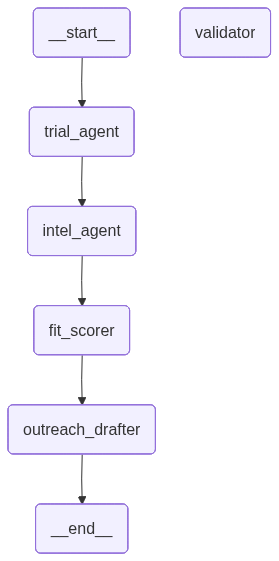

In [33]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Optional
from IPython.display import Image, display

# ── Step 1: Define the state schema ───────────────────────────────────────
# TypedDict is like a Pydantic model but simpler — just type annotations.
# This is the single object that flows through every node in the graph.
# Each node reads from it and returns a PARTIAL update (only the keys it changed).

class ARIAState(TypedDict):
    company_name: str
    trial_data:   dict          # filled by Trial Agent
    intel_data:   dict          # filled by Intel Agent
    fit_score:    dict          # filled by Fit Scorer
    outreach:     str           # filled by Outreach Drafter
    errors:       List[str]     # any node can append errors here
    # validator:    dict

# ── Step 2: Define nodes — each is just a Python function ─────────────────
# For now these are stubs. We'll make them real in the next sections.

def trial_agent_node(state: ARIAState) -> dict:
    print(f"  [Trial Agent] running for: {state['company_name']}")
    # Returns only the keys this node updates — LangGraph merges into state
    return {"trial_data": {"stub": "trial data from ClinicalTrials.gov"}}

def intel_agent_node(state: ARIAState) -> dict:
    print(f"  [Intel Agent] running, trial_data available: {bool(state['trial_data'])}")
    return {"intel_data": {"stub": "news and pipeline intel"}}

def fit_scorer_node(state: ARIAState) -> dict:
    print(f"  [Fit Scorer] scoring based on trial + intel data")
    return {"fit_score": {"score": 72, "rationale": "stub"}}

# def validator_node(state: ARIAState) -> dict:
#     print(f"  [Validator] scoring based on fit score")
    
#     return {"validator":  {"rationale": "stub"}}

# def router(state: ARIAState) -> str:
#     return "outreach_drafter" if state["fit_score"]["score"] > 50 else END

def outreach_drafter_node(state: ARIAState) -> dict:
    print(f"  [Outreach Drafter] drafting email, fit score: {state['fit_score']['score']}")
    return {"outreach": "Dear [Sponsor], ..."}

# ── Step 3: Build and compile the graph ───────────────────────────────────

def build_aria_graph():
    graph = StateGraph(ARIAState)

    # Register nodes
    graph.add_node("trial_agent",      trial_agent_node)
    graph.add_node("intel_agent",      intel_agent_node)
    graph.add_node("fit_scorer",       fit_scorer_node)
    graph.add_node("validator",         validator_node)
    graph.add_node("outreach_drafter", outreach_drafter_node)

    # Define edges (execution order)
    graph.set_entry_point("trial_agent")
    graph.add_edge("trial_agent",      "intel_agent")
    graph.add_edge("intel_agent",      "fit_scorer")
    # graph.add_edge("fit_scorer",       "validator")
    graph.add_edge("fit_scorer",       "outreach_drafter")

    # graph.add_conditional_edges('validator',router,{
    #         "outreach_drafter": "outreach_drafter",
    #         END:END
    #     })
    graph.add_edge("outreach_drafter", END)
    
    return graph.compile()

aria_graph = build_aria_graph()

# ── Step 4: Run the graph ─────────────────────────────────────────────────
print("Running ARIA graph...\n")

initial_state = {
    "company_name": "Pfizer",
    "trial_data":   {},
    "intel_data":   {},
    "fit_score":    {},
    "outreach":     "",
    "errors":       [],
}

final_state = aria_graph.invoke(initial_state)

print("\nFinal state keys filled:", [k for k, v in final_state.items() if v])
print("Fit score:", final_state["fit_score"])
print("Outreach preview:", final_state["outreach"][:50])

display(Image(aria_graph.get_graph().draw_mermaid_png()))

**Key things to notice:**
- Each node function returns only a **partial dict** — just the keys it changed. LangGraph merges it into the full state automatically.
- The graph ran all 4 nodes in sequence without you writing any loop or orchestration code.
- `final_state` has all keys populated — each agent's output is preserved.

**Challenge 2:** Add a 5th node called `validator_node` that checks whether `fit_score["score"] >= 50`. If yes, return `{"outreach": state["outreach"]}` unchanged. If no, return `{"outreach": "", "errors": ["Score too low — skip outreach"]}`. Insert it between `fit_scorer` and `outreach_drafter` using `graph.add_edge`.

---
## Concept 3 — Agent State Management

State is the backbone of multi-agent systems. Three rules:

1. **Read-only from prior nodes** — a node should never assume it knows what previous nodes wrote. Always check if a key is populated.
2. **Partial returns only** — return a dict with only the keys you changed. Returning the full state risks accidentally overwriting another node's work.
3. **Errors are first-class** — don't raise exceptions inside nodes. Append to `state["errors"]` and let the graph continue (or route to a recovery node).

In [34]:
import httpx, asyncio

# A real Trial Agent node — replaces the stub above.
# Reads company_name from state, calls ClinicalTrials.gov, writes trial_data.

async def fetch_trials_real(company_name: str) -> list:
    params = {
        "query.spons": company_name,
        "filter.overallStatus": "RECRUITING,ACTIVE_NOT_RECRUITING",
        "fields": "NCTId,BriefTitle,Phase,Condition,OverallStatus",
        "pageSize": 10,
        "format": "json",
    }
    async with httpx.AsyncClient(timeout=20.0) as http:
        r = await http.get("https://clinicaltrials.gov/api/v2/studies", params=params)
        r.raise_for_status()
        data = r.json()

    results = []
    for study in data.get("studies", []):
        proto = study.get("protocolSection", {})
        results.append({
            "nct_id":    proto.get("identificationModule", {}).get("nctId"),
            "title":     proto.get("identificationModule", {}).get("briefTitle"),
            "phase":     (proto.get("designModule", {}).get("phases") or [None])[0],
            "condition": (proto.get("conditionsModule", {}).get("conditions") or [None])[0],
            "status":    proto.get("statusModule", {}).get("overallStatus"),
        })
    return results


def real_trial_agent_node(state: ARIAState) -> dict:
    """
    Real Trial Agent — fetches live trial data and writes structured summary to state.
    Demonstrates safe state management: catches errors, writes to errors list.
    """
    company = state["company_name"]
    print(f"  [Trial Agent] fetching trials for {company}...")

    try:
        trials = asyncio.run(fetch_trials_real(company))
    except Exception as e:
        # Rule 3: errors are first-class — never raise inside a node
        return {"errors": state.get("errors", []) + [f"Trial Agent fetch failed: {e}"]}

    # Build a structured summary — only what downstream agents need
    phase_counts: dict = {}
    conditions: list = []
    for t in trials:
        if t["phase"]:
            phase_counts[t["phase"]] = phase_counts.get(t["phase"], 0) + 1
        if t["condition"] and t["condition"] not in conditions:
            conditions.append(t["condition"])

    print(f"  [Trial Agent] found {len(trials)} trials, phases: {phase_counts}")

    # Rule 2: return ONLY the keys this node owns
    return {
        "trial_data": {
            "total": len(trials),
            "phase_counts": phase_counts,
            "sample_conditions": conditions[:5],
            "raw": trials,
        }
    }


# Test the node in isolation — before wiring it into the graph
test_state: ARIAState = {
    "company_name": "Regeneron",
    "trial_data": {}, "intel_data": {}, "fit_score": {}, "outreach": "", "errors": []
}

update = real_trial_agent_node(test_state)
print("\nNode returned update keys:", list(update.keys()))
print("Phase counts:", update["trial_data"]["phase_counts"])
print("Sample conditions:", update["trial_data"]["sample_conditions"])

  [Trial Agent] fetching trials for Regeneron...

Node returned update keys: ['errors']


/var/folders/s3/vnj7v2d16qxdvttkkjy3rqph0000gn/T/ipykernel_3596/3428937999.py:44: RuntimeWarning: coroutine 'fetch_trials_real' was never awaited
  return {"errors": state.get("errors", []) + [f"Trial Agent fetch failed: {e}"]}


KeyError: 'trial_data'

---
## Concept 4 — The ReAct Pattern

**ReAct = Reasoning + Acting**. It's the loop that turns a single LLM call into an agent that can take multiple actions before producing a final answer.

The loop:
```
Think → Act (call a tool) → Observe (get tool result) → Think again → Act again → ... → Answer
```

In Anthropic's API, you can see this happening through `stop_reason`:
- `stop_reason = "tool_use"` → Claude wants to act (call a tool), keep looping
- `stop_reason = "end_turn"` → Claude is done reasoning, return the answer

In Phase 1, you did one tool call and stopped. A ReAct agent runs this loop **until Claude decides it has enough information** — it might call a tool 3 times before answering.

In [37]:
# ── ReAct loop implementation ─────────────────────────────────────────────
# This is the core pattern used in every agent node in Phase 2.
# The while loop runs until Claude stops asking for tools.

# Two tools for a simple intel agent to choose from
intel_tools = [
    {
        "name": "get_trial_count",
        "description": "Get count of active trials for a company by phase",
        "input_schema": {
            "type": "object",
            "properties": {
                "company": {"type": "string"},
                "phase":   {"type": "string", "description": "e.g. PHASE2, PHASE3"}
            },
            "required": ["company"]
        }
    },
    {
        "name": "get_therapeutic_areas",
        "description": "Get the main therapeutic areas a company is active in",
        "input_schema": {
            "type": "object",
            "properties": {
                "company": {"type": "string"}
            },
            "required": ["company"]
        }
    }
]

# Fake tool implementations (to avoid live API calls for this demo)
def run_tool(name: str, inputs: dict) -> str:
    if name == "get_trial_count":
        company = inputs["company"]
        phase   = inputs.get("phase", "all")
        # In production this calls ClinicalTrials.gov — here we fake it
        fake_counts = {"Regeneron": {"PHASE2": 14, "PHASE3": 8, "all": 26}}
        count = fake_counts.get(company, {}).get(phase, 5)
        return json.dumps({"company": company, "phase": phase, "count": count})
    elif name == "get_therapeutic_areas":
        fake_tas = {"Regeneron": ["Oncology", "Ophthalmology", "Immunology", "Rare Disease"]}
        return json.dumps({"therapeutic_areas": fake_tas.get(inputs["company"], ["Unknown"])})

# ── The ReAct loop ────────────────────────────────────────────────────────

def run_react_agent(question: str, max_iterations: int = 5) -> str:
    """
    Runs a ReAct loop until Claude returns a final answer (stop_reason = end_turn).
    max_iterations prevents infinite loops — a critical safety guard in production.
    """
    messages = [{"role": "user", "content": question}]
    iteration = 0

    while iteration < max_iterations:
        iteration += 1
        print(f"\n--- Iteration {iteration} ---")

        response = client.messages.create(
            model=MODEL,
            max_tokens=500,
            tools=intel_tools,
            system="You are a pharma intelligence analyst. Use the tools available to answer questions with real data. Call multiple tools if needed.",
            messages=messages,
        )

        print(f"stop_reason: {response.stop_reason}")

        # If Claude is done — return its text answer
        if response.stop_reason == "end_turn":
            for block in response.content:
                if hasattr(block, "text"):
                    return block.text
            return "No text response."

        # If Claude wants to use tools — run them all and send results back
        if response.stop_reason == "tool_use":
            # Append Claude's response (with tool_use blocks) to messages
            messages.append({"role": "assistant", "content": response.content})

            # Run each requested tool and collect results
            tool_results = []
            for block in response.content:
                if block.type == "tool_use":
                    print(f"  Claude called: {block.name}({block.input})")
                    result = run_tool(block.name, block.input)
                    print(f"  Tool returned: {result}")
                    tool_results.append({
                        "type": "tool_result",
                        "tool_use_id": block.id,
                        "content": result,
                    })

            # Send all tool results back as a user message
            messages.append({"role": "user", "content": tool_results})

    return "Max iterations reached — agent did not finish."


answer = run_react_agent(
    # "How many Phase 2 and Phase 3 trials does Regeneron have, and what are their main therapeutic areas?"
    'How many Phase 3 trials does Regeneron have?',max_iterations=1
)
print("\n=== FINAL ANSWER ===")
print(answer)


--- Iteration 1 ---
stop_reason: tool_use
  Claude called: get_trial_count({'company': 'Regeneron', 'phase': 'PHASE3'})
  Tool returned: {"company": "Regeneron", "phase": "PHASE3", "count": 8}

=== FINAL ANSWER ===
Max iterations reached — agent did not finish.


**Challenge 4:** Change `max_iterations=5` to `max_iterations=1`. What happens? Now change the question to something that requires only one tool call. Notice how Claude picks the right tool based on the question — you don't direct it.

---
## Concept 5 — Tool Call Failures & Agent Retries

Real tools fail — network timeouts, bad API responses, malformed data. A production agent must handle this without crashing the whole graph.

**Three strategies:**

| Strategy | When to use | Implementation |
|---|---|---|
| **Return error to Claude** | Tool temporarily unavailable | Send `"is_error": true` in `tool_result` |
| **Retry with backoff** | Transient failures (timeout, 503) | Wrap tool execution in a retry loop |
| **Write to `errors` list + continue** | Non-critical tool (agent can proceed without it) | Return `{"errors": [...]}` from node |

In [38]:
import time

# ── Strategy 1: Return error result to Claude so it can reason around it ──

def run_tool_safe(name: str, inputs: dict) -> tuple[str, bool]:
    """
    Returns (result_str, is_error).
    Claude will see the error message and decide whether to retry or proceed.
    """
    try:
        # Simulate a flaky tool — fails 50% of the time
        import random
        if random.random() < 0.5:
            raise ConnectionError("Simulated network timeout")
        result = run_tool(name, inputs)
        return result, False
    except Exception as e:
        return f"Tool failed: {e}", True


# ── Strategy 2: Retry with exponential backoff ────────────────────────────

def run_tool_with_retry(name: str, inputs: dict, max_retries: int = 3) -> str:
    """
    Retries the tool call up to max_retries times with exponential backoff.
    Raises after all retries exhausted — caller decides whether to error-out.
    """
    for attempt in range(max_retries):
        try:
            return run_tool(name, inputs)
        except Exception as e:
            wait = 2 ** attempt          # 1s, 2s, 4s
            print(f"  Attempt {attempt+1} failed ({e}). Retrying in {wait}s...")
            if attempt < max_retries - 1:
                time.sleep(wait)
    raise RuntimeError(f"Tool '{name}' failed after {max_retries} attempts")


# ── Putting it together: a resilient ReAct loop ───────────────────────────

def run_react_agent_resilient(question: str, max_iterations: int = 5) -> dict:
    """
    Same ReAct loop as before, but with error handling for tool failures.
    Returns {"answer": str, "errors": list} so callers get full visibility.
    """
    messages = [{"role": "user", "content": question}]
    errors = []
    iteration = 0

    while iteration < max_iterations:
        iteration += 1
        response = client.messages.create(
            model=MODEL, max_tokens=500,
            tools=intel_tools,
            system="You are a pharma intelligence analyst. If a tool fails, note it and continue with available data.",
            messages=messages,
        )

        if response.stop_reason == "end_turn":
            answer = next((b.text for b in response.content if hasattr(b, "text")), "")
            return {"answer": answer, "errors": errors}

        if response.stop_reason == "tool_use":
            messages.append({"role": "assistant", "content": response.content})
            tool_results = []

            for block in response.content:
                if block.type == "tool_use":
                    print(f"  Calling: {block.name}({block.input})")
                    result, is_error = run_tool_safe(block.name, block.input)

                    if is_error:
                        errors.append(f"{block.name} failed: {result}")
                        print(f"  ERROR: {result} — sending error to Claude")

                    tool_results.append({
                        "type":        "tool_result",
                        "tool_use_id": block.id,
                        "content":     result,
                        "is_error":    is_error,   # tells Claude the tool failed
                    })

            messages.append({"role": "user", "content": tool_results})

    return {"answer": "Max iterations reached", "errors": errors}


# Run it — may hit simulated errors, watch how Claude responds
result = run_react_agent_resilient(
    "What therapeutic areas is Regeneron active in?"
)
print("\n=== ANSWER ===")
print(result["answer"])
if result["errors"]:
    print("\n=== ERRORS ENCOUNTERED ===")
    for e in result["errors"]:
        print(f"  - {e}")

  Calling: get_therapeutic_areas({'company': 'Regeneron'})
  ERROR: Tool failed: Simulated network timeout — sending error to Claude

=== ANSWER ===
Unfortunately, I encountered a network timeout when trying to retrieve Regeneron's therapeutic area data, so I'm unable to pull live results at this moment.

However, based on my knowledge as a pharma intelligence analyst, **Regeneron** is broadly active in the following therapeutic areas:

- **Ophthalmology** – Most notably with *Eylea (aflibercept)*, used for wet AMD, diabetic macular edema, and other retinal conditions.
- **Immunology & Inflammation** – Including *Dupixent (dupilumab)* for atopic dermatitis, asthma, eosinophilic esophagitis, and other type 2 inflammatory diseases.
- **Oncology** – With programs in hematologic malignancies and solid tumors, including *Libtayo (cemiplimab)* for certain skin and lung cancers.
- **Cardiovascular & Metabolic Disease** – Including *Praluent (alirocumab)*, a PCSK9 inhibitor for LDL cholesterol

---
## Concept 6 — Prompt Design for Agents

Agent system prompts are different from Phase 1 prompts. In Phase 1, the prompt said "output JSON". Agent prompts need to:

1. **Define the agent's role tightly** — what it is, what it is NOT responsible for
2. **Specify what to do with tool results** — how to interpret and what to extract
3. **Define the output contract** — what the next agent downstream expects to receive
4. **Set guardrails** — what the agent should do when data is missing or ambiguous

Compare the same task with a generic vs role-specific prompt below.

In [39]:
# Sample trial data — what the Trial Agent would have written to state
sample_trial_data = {
    "total": 26,
    "phase_counts": {"PHASE2": 14, "PHASE3": 8, "PHASE1": 4},
    "sample_conditions": ["Oncology", "Atopic Dermatitis", "Asthma", "Rare Disease"],
}
sample_user_content = f"Trial data: {json.dumps(sample_trial_data)}\nCompany: Regeneron"

# ── Generic prompt — no role context ──────────────────────────────────────
r_generic = client.messages.create(
    model=MODEL, max_tokens=300,
    system="You are a helpful assistant.",
    messages=[{"role": "user", "content": sample_user_content + "\n\nSummarise this for a sales team."}]
)
print("=== GENERIC PROMPT ===")
print(r_generic.content[0].text)

print("\n" + "─"*60 + "\n")

# ── Role-specific agent prompt ─────────────────────────────────────────────
FIT_SCORER_SYSTEM = """You are the Fit Scorer agent in an agentic CRO business development system.

Your ONLY job: score a pharma sponsor's fit against the CRO's capability profile.
You are NOT responsible for writing emails, fetching data, or making recommendations.

CRO capability profile (fixed):
- Strong in: Oncology Phase 2/3, Rare Disease, Immunology
- Weaker in: CNS, Cardiovascular, Gene Therapy Phase 1

Scoring dimensions (weights must sum to 1.0):
  therapeutic_area_match: 0.30  — does their TA align with CRO strengths?
  phase_capability:       0.25  — do their active phases match CRO capacity?
  geographic_overlap:     0.20  — are trial sites where CRO operates?
  deal_size_fit:          0.15  — is the pipeline scale right for CRO?
  competitive_timing:     0.10  — are they likely to need a CRO soon?

CRITICAL: Return ONLY valid JSON:
{
  "score": <int 0-100>,
  "dimensions": {"therapeutic_area_match": <int>, "phase_capability": <int>, ...},
  "rationale": "<2 sentence explanation>",
  "top_opportunity": "<single best angle for the BD rep>"
}
If data is missing for a dimension, score it 50 (neutral) and note it in rationale."""

r_agent = client.messages.create(
    model=MODEL, max_tokens=400,
    system=FIT_SCORER_SYSTEM,
    messages=[{"role": "user", "content": sample_user_content}]
)
print("=== ROLE-SPECIFIC AGENT PROMPT ===")
print(r_agent.content[0].text)

=== GENERIC PROMPT ===
## Regeneron Clinical Pipeline Summary

**For Internal Sales Use**

---

### Pipeline at a Glance
Regeneron currently has **26 active clinical trials** across its portfolio, demonstrating a robust and maturing development pipeline.

---

### Phase Breakdown
| Phase | Trials | What This Means |
|-------|--------|-----------------|
| **Phase 2** | 14 | Strong mid-stage pipeline with significant assets in development |
| **Phase 3** | 8 | Near-term commercial opportunities approaching market readiness |
| **Phase 1** | 4 | Early innovation feeding the longer-term pipeline |

---

### Key Therapeutic Areas
- 🎗️ **Oncology**
- 🩹 **Atopic Dermatitis**
- 🫁 **Asthma**
- 🔬 **Rare Disease**

---

### Key Talking Points for Sales
- **8 Phase 3 trials** signal potential near-term launches — valuable for forward-looking conversations with customers
- Breadth across **immunology and oncology** reflects Regeneron's established strengths *(e.g., Dupixent platform)*
- Rare Diseas

In [44]:
# ── Role-specific agent prompt ─────────────────────────────────────────────
OUTREACH_DRAFTER_SYSTEM = """You are the Outreach Drafter agent in an agentic CRO business development system.

Your ONLY job: draft a personalised outreach email to a pharma sponsor.
You are NOT responsible for scoring fits, fetching data, or making recommendations.

Email structure:
- Subject line: [CRO Name] - [Sponsor Name] Collaboration Opportunity
- Greeting: Dear [Sponsor Contact Name],
- Body: Brief introduction of CRO capabilities relevant to the sponsor's pipeline
    - if fit_score < 60, open with soft touch rather than hard pitch
    - else lead with strong fit and specific relevant capabilities
- Call-to-action: Request for a meeting or call to discuss potential collaboration
- Closing: Thank you for your time and consideration

CRITICAL: Return ONLY valid JSON:
{
  "subject": "<subject line>",
  "body": "<email body>"
}
If data is missing for any field, use placeholders and note it in rationale."""

r_outreach_agent = client.messages.create(
    model=MODEL, max_tokens=400,
    system=OUTREACH_DRAFTER_SYSTEM,
    messages=[{"role": "user", "content": sample_user_content}]
)
print("=== ROLE-SPECIFIC AGENT PROMPT ===")
print(r_outreach_agent.content[0].text)

=== ROLE-SPECIFIC AGENT PROMPT ===
```json
{
  "subject": "Precision CRO - Regeneron Collaboration Opportunity",
  "body": "Dear [Sponsor Contact Name],\n\nI hope this message finds you well. My name is [CRO Representative Name] from Precision CRO, and I am reaching out because we believe there is a compelling alignment between our clinical development capabilities and Regeneron's impressive and diverse pipeline.\n\nWith 26 active trials spanning Phase I through Phase III, and a therapeutic focus spanning Oncology, Atopic Dermatitis, Asthma, and Rare Diseases, Regeneron is clearly driving innovation across some of the most complex and high-need areas in medicine. At Precision CRO, we are purpose-built to support exactly this kind of multi-indication, multi-phase portfolio:\n\n• **Oncology Expertise:** Our dedicated oncology unit has deep experience in complex solid tumor and hematology trial designs, biomarker-driven patient selection, and adaptive trial methodologies ideally suited to

**Challenge 6:** Write the system prompt for the **Outreach Drafter Agent**. It should:
- Have a specific persona (BD rep, not analyst)
- Define exactly what it receives as input (fit score + trial data)
- Define its output contract (subject line + 3-paragraph email)
- Include a guardrail: if `fit_score < 60`, open with a soft touch rather than a hard pitch

---
## Concept 7 — Conditional Routing

So far every graph edge is fixed: A → B → C → D. **Conditional routing** lets the graph branch based on what an agent found.

In ARIA: if the Fit Scorer returns a score < 40, there's no point drafting an outreach email. The graph should route to END (or a "low-fit" logging node) instead.

LangGraph uses `add_conditional_edges` for this — you pass a function that returns the name of the next node.

=== Run 1: Low score (35) ===


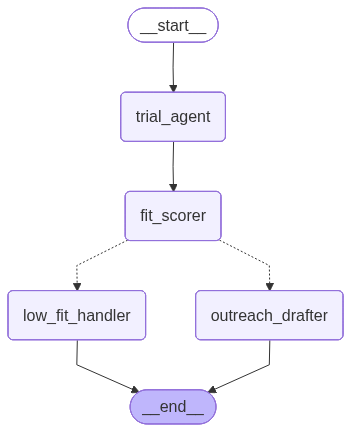

  [Trial Agent] running for: SmallBiotech
  [Router] Score 70 ≥ 60 → routing to outreach_drafter
Outreach: 'Dear [Sponsor], your fit score is 70...'
Errors: []


In [53]:
from langgraph.graph import StateGraph, END

# ── Router function — decides next node based on state ────────────────────
# This function is called by LangGraph after fit_scorer_node runs.
# It receives the current state and returns a string: the name of the next node.

def route_after_scoring(state: ARIAState) -> str:
    score = state.get("fit_score", {}).get("score", 0)
    if score >= 60:
        print(f"  [Router] Score {score} ≥ 60 → routing to outreach_drafter")
        return "outreach_drafter"
    else:
        print(f"  [Router] Score {score} < 60 → routing to low_fit_handler")
        return "low_fit_handler"


# ── Low-fit handler node ───────────────────────────────────────────────────
def low_fit_handler_node(state: ARIAState) -> dict:
    score = state["fit_score"].get("score", 0)
    print(f"  [Low Fit Handler] score={score}, logging and skipping outreach")
    return {
        "outreach": "",
        "errors": state.get("errors", []) + [f"Fit score {score} too low — outreach skipped"]
    }


# ── Stub nodes for this demo ───────────────────────────────────────────────
def fit_scorer_stub(state: ARIAState) -> dict:
    # Try changing this score to 75 and re-run to see the routing change
    return {"fit_score": {"score": 70, "rationale": "Weak TA overlap"}}

def outreach_drafter_stub(state: ARIAState) -> dict:
    return {"outreach": f"Dear [Sponsor], your fit score is {state['fit_score']['score']}..."}


# ── Build graph with conditional routing ──────────────────────────────────
def build_conditional_graph():
    graph = StateGraph(ARIAState)

    graph.add_node("trial_agent",      trial_agent_node)       # stub from Concept 2
    graph.add_node("fit_scorer",       fit_scorer_stub)
    graph.add_node("outreach_drafter", outreach_drafter_stub)
    graph.add_node("low_fit_handler",  low_fit_handler_node)

    graph.set_entry_point("trial_agent")
    graph.add_edge("trial_agent", "fit_scorer")

    # Conditional edge — calls route_after_scoring to decide next node
    graph.add_conditional_edges(
        "fit_scorer",          # from this node...
        route_after_scoring,   # ...call this function to decide...
        {                      # ...and map its return value to node names
            "outreach_drafter": "outreach_drafter",
            "low_fit_handler":  "low_fit_handler",
        }
    )

    graph.add_edge("outreach_drafter", END)
    graph.add_edge("low_fit_handler",  END)

    return graph.compile()


# Run with low score (35) — should route to low_fit_handler
print("=== Run 1: Low score (35) ===")
g = build_conditional_graph()
display(Image(g.get_graph().draw_mermaid_png()))
s1 = g.invoke({"company_name": "SmallBiotech", "trial_data": {}, "intel_data": {},
                "fit_score": "", "outreach": "", "errors": []})
print("Outreach:", repr(s1["outreach"]))
print("Errors:", s1["errors"])

# Now try with a high score — edit fit_scorer_stub above to score=75 and re-run

---
## Concept 8 — Observability: Tracing Agent Runs

When a single LLM call goes wrong you can print the output. When a 4-agent graph goes wrong across 8 tool calls and 3 LLM turns, you need a trace.

**What LangSmith gives you:**
- Every node's input state and output state, side by side
- Every LLM call's exact prompt, response, and token count
- Latency per node — so you know which agent is slow
- A shareable run URL for debugging with teammates

**Setup:** requires a free LangSmith account at smith.langchain.com. Add `LANGSMITH_API_KEY` to your `.env`.

Below: a manual lightweight tracer you can use right now without LangSmith — good for understanding what LangSmith is doing under the hood.

In [ ]:
import time
from dataclasses import dataclass, field

# ── A minimal run tracer ──────────────────────────────────────────────────
# This is what LangSmith does automatically. Building it manually
# helps you understand what observability actually captures.

@dataclass
class NodeTrace:
    name:        str
    started_at:  float = field(default_factory=time.time)
    ended_at:    float = 0.0
    input_keys:  list  = field(default_factory=list)
    output_keys: list  = field(default_factory=list)
    llm_calls:   int   = 0
    tokens_used: int   = 0
    error:       str   = ""

    @property
    def duration_ms(self):
        return round((self.ended_at - self.started_at) * 1000)


class RunTracer:
    def __init__(self, run_name: str):
        self.run_name = run_name
        self.traces: list[NodeTrace] = []
        self._current: NodeTrace | None = None

    def start_node(self, name: str, state: dict):
        self._current = NodeTrace(
            name=name,
            input_keys=[k for k, v in state.items() if v]
        )
        print(f"  ▶ {name} started")

    def record_llm_call(self, input_tokens: int, output_tokens: int):
        if self._current:
            self._current.llm_calls += 1
            self._current.tokens_used += input_tokens + output_tokens

    def end_node(self, update: dict, error: str = ""):
        if self._current:
            self._current.ended_at = time.time()
            self._current.output_keys = list(update.keys())
            self._current.error = error
            self.traces.append(self._current)
            status = "✓" if not error else "✗"
            print(f"  {status} {self._current.name} done ({self._current.duration_ms}ms, {self._current.tokens_used} tokens)")
            self._current = None

    def print_summary(self):
        print(f"\n{'═'*50}")
        print(f"RUN TRACE: {self.run_name}")
        print(f"{'═'*50}")
        total_tokens = 0
        for t in self.traces:
            status = "ERROR" if t.error else "OK"
            print(f"  {t.name:<22} {status:<8} {t.duration_ms:>6}ms  {t.tokens_used:>5} tokens  LLM calls: {t.llm_calls}")
            total_tokens += t.tokens_used
        print(f"{'─'*50}")
        print(f"  {'TOTAL':<22} {'':8} {'':>6}    {total_tokens:>5} tokens")


# ── Traced versions of agents ─────────────────────────────────────────────
# In production, LangSmith wraps nodes automatically.
# Here we wrap manually to show what's being captured.

tracer = RunTracer("ARIA test run — Regeneron")

def traced_trial_agent(state: ARIAState) -> dict:
    tracer.start_node("trial_agent", state)
    update = real_trial_agent_node(state)           # the real node from Concept 3
    tracer.end_node(update)
    return update

def traced_fit_scorer(state: ARIAState) -> dict:
    tracer.start_node("fit_scorer", state)
    # Make a real LLM call and record it
    r = client.messages.create(
        model=MODEL, max_tokens=300,
        system=FIT_SCORER_SYSTEM,
        messages=[{"role": "user", "content": f"Trial data: {json.dumps(state.get('trial_data', {}))}"}]
    )
    tracer.record_llm_call(r.usage.input_tokens, r.usage.output_tokens)
    try:
        parsed = json.loads(r.content[0].text)
    except Exception:
        parsed = {"score": 50, "rationale": "Parse failed", "dimensions": {}, "top_opportunity": ""}
    update = {"fit_score": parsed}
    tracer.end_node(update)
    return update

def traced_outreach_drafter(state: ARIAState) -> dict:
    tracer.start_node("outreach_drafter", state)
    score = state.get("fit_score", {}).get("score", 0)
    update = {"outreach": f"[Score: {score}] Dear team at {state['company_name']}..."}
    tracer.end_node(update)
    return update

# ── Build and run the traced graph ────────────────────────────────────────
from langgraph.graph import StateGraph, END

traced_graph = StateGraph(ARIAState)
traced_graph.add_node("trial_agent",      traced_trial_agent)
traced_graph.add_node("fit_scorer",       traced_fit_scorer)
traced_graph.add_node("outreach_drafter", traced_outreach_drafter)
traced_graph.set_entry_point("trial_agent")
traced_graph.add_edge("trial_agent",      "fit_scorer")
traced_graph.add_edge("fit_scorer",       "outreach_drafter")
traced_graph.add_edge("outreach_drafter", END)
compiled = traced_graph.compile()

print("Running traced graph...\n")
final = compiled.invoke({
    "company_name": "Regeneron",
    "trial_data": {}, "intel_data": {}, "fit_score": {}, "outreach": "", "errors": []
})

tracer.print_summary()
print(f"\nFit score: {final['fit_score'].get('score')}/100")
print(f"Top opportunity: {final['fit_score'].get('top_opportunity', 'N/A')}")

---
## Summary

| Concept | What you built | Where in Phase 2 app |
|---|---|---|
| Why multi-agent | Compared single-prompt vs pipeline quality | Architecture rationale |
| LangGraph fundamentals | 4-node graph with real compiled execution | `agents/graph.py` |
| Agent state management | Real Trial Agent node with error-safe partial returns | `agents/trial_agent.py` |
| ReAct pattern | while loop on `stop_reason`, multi-tool iteration | `agents/intel_agent.py` |
| Tool failure & retries | `is_error` flag + exponential backoff | All agent nodes |
| Agent prompt design | Role-specific Fit Scorer vs generic prompt, output contract | `agents/fit_scorer.py` |
| Conditional routing | `add_conditional_edges` + router function | `agents/graph.py` |
| Observability | Manual `RunTracer` → same data LangSmith collects automatically | `config.py` LANGSMITH_API_KEY |

**What's missing from this notebook vs the full Phase 2 app:**
- **Intel Agent** — uses Anthropic's built-in `web_search_20250305` tool (requires API key to enable, covered when we build the app)
- **LangSmith integration** — swap `RunTracer` for real tracing with `LANGSMITH_TRACING=true` in `.env`

You're ready to start building Phase 2. Let me know when you want to begin.